<a href="https://colab.research.google.com/github/agus-beep952/Estadisticaverano2026/blob/main/gymmembers/Gym_members.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problema. Optimización de sesiones de entrenamiento
La cadena de gimnasios FitLife ha recopilado información de cientos de socios con el objetivo de comprender mejor qué factores influyen en el gasto calórico durante una sesión de entrenamiento. El gerente considera que la duración de la sesión podría ser un buen predictor de las calorías quemadas, pero desea comprobar si realmente existe una relación lineal suficientemente fuerte como para utilizarla en la planeación de rutinas personalizadas.

Para ello, pone a tu disposición la base de datos Gym Members Exercise Dataset, la cual contiene información de 973 sesiones de entrenamiento, incluyendo variables como edad, peso, estatura, frecuencia cardiaca, duración de la sesión, tipo de entrenamiento, frecuencia semanal y calorías quemadas: base de datos

Prepara un informe con tus hallazgos y recomendaciones. El informe debe estar libre de código: sólo debe incluir gráficos, tablas y estadísticos que sustenten lo que se menciona. Al final, prepara una recomendación general para el gimnasio.

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/agus-beep952/Estadisticaverano2026/refs/heads/main/gymmembers/gym_members_exercise_tracking.csv")

df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [ ]:
df.rename(columns={
 "Session_Duration (hours)":"Session_Duration"
},inplace=True)

In [ ]:
X=df["Session_Duration"]#variable independiente
Y=df["Calories_Burned"]# variable independiente

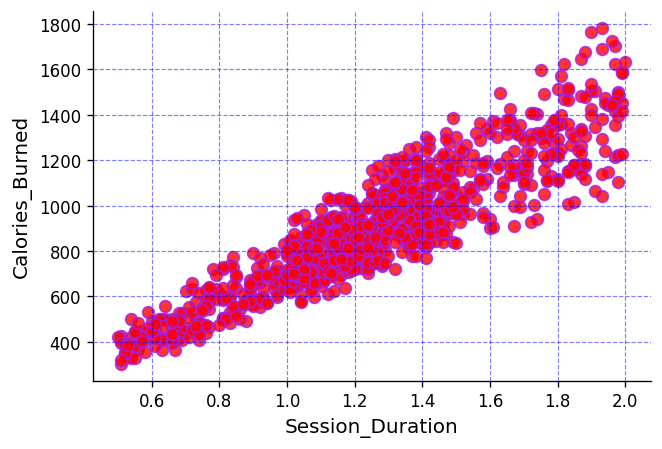

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9081
valor_p:  0.0000


In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)

In [ ]:
# Coeficiente de determinacion
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinacion: {r2: 0.2%}")

Coeficiente de determinacion:  82.47%


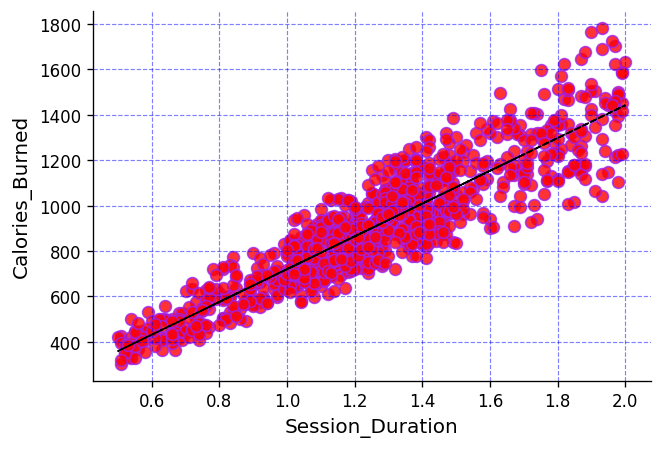

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada,
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [ ]:
residuales = modelo.resid

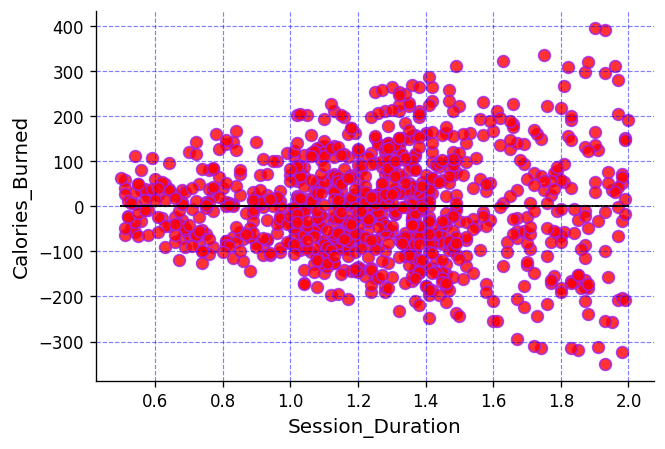

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X,residuales,      # <---------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada * 0,# <---------------------------------------------------------
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y #<-----------------------------------------
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [ ]:
modelo.params

,0
const,-1.446459
Session_Duration,721.786016


valor-p (Shapiro) = 0.003841645423152361


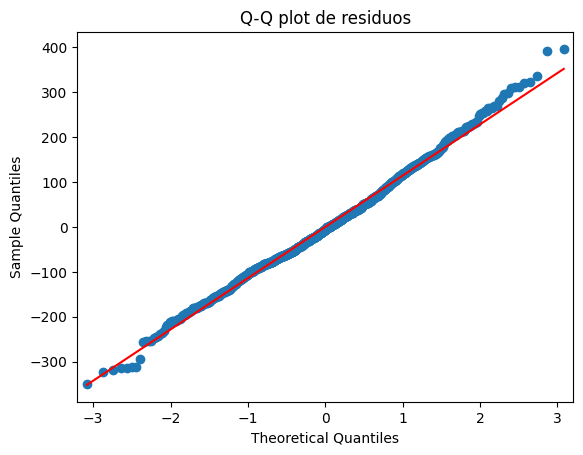

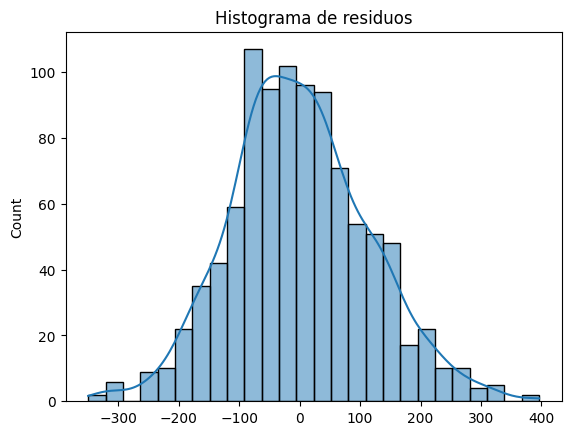

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#test de shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000

